# Experimento: Bifurcación Topológica UMAP en n_neighbors=20
## QQQ Regime Clustering — Análisis de Reproducibilidad

**Hipótesis a validar:**
> El parámetro `n_neighbors=20` ubica el embedding UMAP del dataset QQQ
> en un punto de bifurcación topológica donde HDBSCAN puede converger
> a dos soluciones estables: ~2 clusters (estructura global) o ~21 clusters
> (micro-regímenes locales). Valores por fuera de ese rango son estables.

---

### Diseño experimental: 4 fases

| Fase | Qué mide | Qué falsifica |
|------|----------|---------------|
| **A** | Sweep n_neighbors [5→50], 15 repeticiones/valor | Si n=20 es el ÚNICO inestable |
| **B** | Perturbación controlada del embedding en n=20 vs n=15 | Si la inestabilidad es sensibilidad geométrica real |
| **C** | Análisis de geometría del embedding (distancias, densidad) | Si la bifurcación es estructural o estadística |
| **D** | Simulación de cambios entre sesiones (reinicio de RNG) | Si el JIT de Numba es la causa o el dato |

---

### Condiciones de falsificación

La hipótesis es **FALSA** si cualquiera de estas se cumple:
1. `n=20` siempre produce el mismo resultado en 15 repeticiones.
2. Otros valores de n también muestran alta varianza de clusters.
3. La inestabilidad aparece en datos sintéticos con estructura conocida.
4. El embedding hash es idéntico entre runs que producen conteos distintos.

La hipótesis es **VERDADERA** si:
1. `n=20` produce distribución bimodal (2 Y 21 clusters) en repeticiones.
2. `n=15` y `n=25` son estables y distintos entre sí.
3. Perturbaciones mínimas en n=20 cambian el conteo dramáticamente.
4. El embedding hash cambia cuando cambia el conteo.


## Setup

In [1]:
# ============================================================
# SETUP
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import umap
import hdbscan
import hashlib, time, os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.stats import entropy
from collections import Counter

print(f"umap-learn : {umap.__version__}")
print(f"numpy      : {np.__version__}")
print(f"pandas     : {pd.__version__}")

# ── Parámetros del proyecto original ─────────────────────
RANDOM_STATE        = 42
MIN_CLUSTER_SIZE    = 12
MIN_SAMPLES         = 6
MIN_DIST            = 0.05
ORIGINAL_N_NEIGHBORS = 20

FEATURE_COLS = [
    "returns",
    "vol_4", "vol_13", "vol_26",
    "mom_4", "mom_13", "mom_26", "mom_52",
    "trend_13_52", "sma13_slope", "price_vs_sma_52",
    "breakout_13", "breakout_26", "breakdown_13",
    "range_position_13", "atr_pct", "drawdown", "vol_rel_4",
]

print(f"\nFeatures del proyecto: {len(FEATURE_COLS)}")
print(f"Parámetros: n_neighbors={ORIGINAL_N_NEIGHBORS}, min_cluster_size={MIN_CLUSTER_SIZE}, min_samples={MIN_SAMPLES}")


umap-learn : 0.5.11
numpy      : 2.3.5
pandas     : 3.0.0

Features del proyecto: 18
Parámetros: n_neighbors=20, min_cluster_size=12, min_samples=6


## Carga de datos

**Prioridad:** CSV congelado si existe → yfinance si no.
Usar CSV congelado es crítico para aislar la fuente de variabilidad:
si los datos son exactamente los mismos, cualquier variación proviene
de UMAP/Numba, no de yfinance.


In [2]:
# ============================================================
# CARGA DE DATOS — CSV congelado preferido
# ============================================================

def flatten_yf_columns(df):
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
    return df

def add_weekly_features(df):
    df    = df.copy()
    price = df["Close"].copy()
    df["returns"]     = price.pct_change()
    df["log_returns"] = np.log(price / price.shift(1))
    df["vol_4"]  = df["returns"].rolling(4).std()
    df["vol_13"] = df["returns"].rolling(13).std()
    df["vol_26"] = df["returns"].rolling(26).std()
    df["mom_4"]  = price / price.shift(4)  - 1
    df["mom_13"] = price / price.shift(13) - 1
    df["mom_26"] = price / price.shift(26) - 1
    df["mom_52"] = price / price.shift(52) - 1
    df["sma_4"]  = price.rolling(4).mean()
    df["sma_13"] = price.rolling(13).mean()
    df["sma_26"] = price.rolling(26).mean()
    df["sma_52"] = price.rolling(52).mean()
    df["trend_13_52"]      = df["sma_13"] / df["sma_52"] - 1
    df["price_vs_sma_52"]  = price / df["sma_52"] - 1
    df["sma13_slope"]      = df["sma_13"].pct_change(3)
    df["high_13"]          = df["High"].rolling(13).max()
    df["low_13"]           = df["Low"].rolling(13).min()
    df["breakout_13"]      = price / df["high_13"] - 1
    df["breakdown_13"]     = price / df["low_13"]  - 1
    df["high_26"]          = df["High"].rolling(26).max()
    df["breakout_26"]      = price / df["high_26"] - 1
    range_13               = (df["high_13"] - df["low_13"]).replace(0, np.nan)
    df["range_position_13"]= (price - df["low_13"]) / range_13
    tr1 = df["High"] - df["Low"]
    tr2 = (df["High"] - df["Close"].shift(1)).abs()
    tr3 = (df["Low"]  - df["Close"].shift(1)).abs()
    df["tr"]      = np.maximum.reduce([tr1.values, tr2.values, tr3.values])
    df["atr_4"]   = df["tr"].rolling(4).mean()
    df["atr_13"]  = df["tr"].rolling(13).mean()
    df["atr_pct"] = df["atr_13"] / price
    df["cummax"]  = price.cummax()
    df["drawdown"]= price / df["cummax"] - 1
    df["vol_rel_4"] = df["Volume"] / df["Volume"].rolling(4).mean()
    return df.dropna().copy()

# Intentar CSV congelado primero
CSV_PATH = "qqq_weekly_frozen.csv"

if os.path.exists(CSV_PATH):
    raw = pd.read_csv(CSV_PATH, index_col=0, parse_dates=True)
    # Si tiene columnas OHLCV reconstruir features; si ya tiene features usarlos directamente
    if "returns" not in raw.columns:
        weekly = add_weekly_features(raw)
    else:
        weekly = raw.copy()
    DATA_SOURCE = "CSV congelado"
else:
    import yfinance as yf
    daily_raw  = yf.download("QQQ", start="2000-01-01", auto_adjust=True, progress=False)
    daily_raw  = flatten_yf_columns(daily_raw).dropna()
    weekly_raw = daily_raw.resample("W-FRI").agg({
        "Open":"first","High":"max","Low":"min","Close":"last","Volume":"sum"
    }).dropna()
    weekly = add_weekly_features(weekly_raw)
    # Guardar para futuras corridas
    weekly.to_csv(CSV_PATH)
    DATA_SOURCE = "yfinance (guardado como CSV)"

Xs = StandardScaler().fit_transform(weekly[FEATURE_COLS])
DATA_HASH = hashlib.sha256(Xs.tobytes()).hexdigest()[:12]

print(f"Fuente       : {DATA_SOURCE}")
print(f"Observaciones: {len(weekly)}")
print(f"Features     : {Xs.shape[1]}")
print(f"Rango        : {weekly.index[0].date()} → {weekly.index[-1].date()}")
print(f"Hash datos   : {DATA_HASH}  (debe ser idéntico en cada corrida)")


Fuente       : yfinance (guardado como CSV)
Observaciones: 1328
Features     : 18
Rango        : 2001-01-05 → 2026-06-12
Hash datos   : 03be65e7a770  (debe ser idéntico en cada corrida)


## Funciones del experimento


In [3]:
# ============================================================
# FUNCIONES DE MÉTRICAS
# ============================================================

def run_single(Xs, n_neighbors, min_dist=0.05,
               min_cluster_size=12, min_samples=6,
               random_state=42, add_noise_std=0.0):
    """
    Ejecuta un ciclo UMAP + HDBSCAN y devuelve métricas completas.
    add_noise_std: si > 0, agrega ruido gaussiano al embedding ANTES de HDBSCAN.
    Permite distinguir si la inestabilidad está en UMAP o en HDBSCAN.
    """
    X = Xs.copy()
    t0 = time.time()

    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=2,
        n_jobs=1,
        random_state=random_state
    )
    emb = reducer.fit_transform(X)

    if add_noise_std > 0:
        rng = np.random.RandomState(random_state)
        emb = emb + rng.normal(0, add_noise_std, emb.shape)

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        cluster_selection_method="eom",
        prediction_data=True
    )
    labels = clusterer.fit_predict(emb)

    elapsed = time.time() - t0

    # ── Métricas ─────────────────────────────────────────
    counts   = Counter(labels)
    n_noise  = counts.get(-1, 0)
    n_clust  = len(counts) - (1 if -1 in counts else 0)
    sizes    = sorted([v for k,v in counts.items() if k != -1], reverse=True)
    max_size = sizes[0] if sizes else 0
    min_size = sizes[-1] if sizes else 0
    size_std = float(np.std(sizes)) if len(sizes) > 1 else 0.0

    # Entropía de distribución de clusters (alta entropía = clusters más uniformes)
    if sizes:
        probs       = np.array(sizes) / sum(sizes)
        clust_entropy = float(entropy(probs))
    else:
        clust_entropy = 0.0

    # Silhouette solo si hay ≥ 2 clusters y no todo es ruido
    non_noise = labels != -1
    if n_clust >= 2 and non_noise.sum() > 50:
        try:
            sil = float(silhouette_score(emb[non_noise], labels[non_noise],
                                         sample_size=min(500, non_noise.sum())))
        except:
            sil = np.nan
    else:
        sil = np.nan

    emb_hash   = hashlib.sha256(emb.tobytes()).hexdigest()[:10]
    label_hash = hashlib.sha256(labels.tobytes()).hexdigest()[:10]

    return {
        "n_neighbors":    n_neighbors,
        "n_clusters":     n_clust,
        "n_anomalies":    n_noise,
        "max_cluster":    max_size,
        "min_cluster":    min_size,
        "size_std":       round(size_std, 1),
        "entropy":        round(clust_entropy, 3),
        "silhouette":     round(sil, 4) if not np.isnan(sil) else np.nan,
        "emb_hash":       emb_hash,
        "label_hash":     label_hash,
        "elapsed_s":      round(elapsed, 1),
        "noise_std_used": add_noise_std,
    }


def sweep_n_neighbors(Xs, nn_values, n_reps, desc=""):
    """Sweep sistemático con n_reps repeticiones por valor de n."""
    results = []
    total   = len(nn_values) * n_reps
    done    = 0
    for nn in nn_values:
        for rep in range(n_reps):
            r = run_single(Xs, n_neighbors=nn, random_state=RANDOM_STATE)
            r["rep"]  = rep
            r["desc"] = desc
            results.append(r)
            done += 1
            if done % 5 == 0:
                print(f"  [{done:3d}/{total}]  n={nn:2d}  rep={rep}  "
                      f"→ {r['n_clusters']:2d} clusters  "
                      f"emb={r['emb_hash']}  lbl={r['label_hash']}")
    return pd.DataFrame(results)


def stability_summary(df_results):
    """Tabla de estabilidad por valor de n_neighbors."""
    grp = df_results.groupby("n_neighbors")
    summary = pd.DataFrame({
        "n_reps":        grp["n_clusters"].count(),
        "n_clust_mean":  grp["n_clusters"].mean().round(1),
        "n_clust_std":   grp["n_clusters"].std().round(2),
        "n_clust_min":   grp["n_clusters"].min(),
        "n_clust_max":   grp["n_clusters"].max(),
        "n_clust_unique":grp["n_clusters"].nunique(),
        "emb_unique":    grp["emb_hash"].nunique(),
        "label_unique":  grp["label_hash"].nunique(),
        "entropy_mean":  grp["entropy"].mean().round(3),
        "silhouette":    grp["silhouette"].mean().round(3),
    })
    # Marcar valores con alta varianza
    summary["INESTABLE"] = (summary["n_clust_std"] > 2) | (summary["n_clust_unique"] > 2)
    return summary

print("Funciones del experimento cargadas.")
print(f"Hash de datos verificado: {DATA_HASH}")


Funciones del experimento cargadas.
Hash de datos verificado: 03be65e7a770


## Fase A — Sweep Sistemático de n_neighbors

**Diseño:** testar n_neighbors = [5, 8, 10, 12, 15, 18, 20, 22, 25, 30, 40, 50]
con **15 repeticiones por valor**, todos dentro de la misma sesión de Python.

**¿Qué mide?** La variabilidad intrínseca del pipeline dado el mismo proceso,
los mismos datos y el mismo random_state. En sesión única, Numba ya está
compilado igual para todos los runs → cualquier diferencia viene de UMAP o HDBSCAN.

**Resultado esperado si la hipótesis ES correcta:**
- `n_clust_std` ≈ 0 para casi todos los valores.
- Un único valor (o rango estrecho) muestra `n_clust_std >> 0`.
- El máximo de `emb_unique` aparece en ese mismo rango.

**Resultado esperado si la hipótesis ES FALSA:**
- Múltiples valores de n muestran alta varianza simultáneamente.
- O n=20 tiene `n_clust_std = 0` (siempre el mismo resultado).


In [4]:
# ============================================================
# FASE A — SWEEP SISTEMÁTICO
# ============================================================

NN_VALUES = [5, 8, 10, 12, 15, 18, 20, 22, 25, 30, 40, 50]
N_REPS_A  = 15

print(f"Fase A: {len(NN_VALUES)} valores × {N_REPS_A} reps = {len(NN_VALUES)*N_REPS_A} corridas")
print(f"Hash datos al inicio: {DATA_HASH}")
print()

results_A = sweep_n_neighbors(Xs, NN_VALUES, N_REPS_A, desc="fase_A")

summary_A = stability_summary(results_A)

print("\n" + "="*70)
print("RESUMEN FASE A")
print("="*70)
display(summary_A)

# Tabla de distribución de conteos por n_neighbors
print("\nDistribución de n_clusters por n_neighbors:")
pivot = results_A.groupby(["n_neighbors","n_clusters"]).size().unstack(fill_value=0)
display(pivot)

# Identificar valores inestables
inestables = summary_A[summary_A["INESTABLE"]].index.tolist()
estables   = summary_A[~summary_A["INESTABLE"]].index.tolist()
print(f"\nValores INESTABLES (std>2 o >2 resultados únicos): {inestables}")
print(f"Valores ESTABLES                                  : {estables}")


Fase A: 12 valores × 15 reps = 180 corridas
Hash datos al inicio: 03be65e7a770

  [  5/180]  n= 5  rep=4  → 24 clusters  emb=25a15e5fde  lbl=9b4ee993d2
  [ 10/180]  n= 5  rep=9  → 24 clusters  emb=25a15e5fde  lbl=9b4ee993d2
  [ 15/180]  n= 5  rep=14  → 24 clusters  emb=25a15e5fde  lbl=9b4ee993d2
  [ 20/180]  n= 8  rep=4  →  9 clusters  emb=c1e7ee0825  lbl=f3f087ee90
  [ 25/180]  n= 8  rep=9  →  9 clusters  emb=c1e7ee0825  lbl=f3f087ee90
  [ 30/180]  n= 8  rep=14  →  9 clusters  emb=c1e7ee0825  lbl=f3f087ee90
  [ 35/180]  n=10  rep=4  →  4 clusters  emb=e239f24155  lbl=095fccaa5c
  [ 40/180]  n=10  rep=9  →  4 clusters  emb=e239f24155  lbl=095fccaa5c
  [ 45/180]  n=10  rep=14  →  4 clusters  emb=e239f24155  lbl=095fccaa5c
  [ 50/180]  n=12  rep=4  → 34 clusters  emb=85a86aaafd  lbl=17e39c8956
  [ 55/180]  n=12  rep=9  → 34 clusters  emb=85a86aaafd  lbl=17e39c8956
  [ 60/180]  n=12  rep=14  → 34 clusters  emb=85a86aaafd  lbl=17e39c8956
  [ 65/180]  n=15  rep=4  → 19 clusters  emb=4fc7925

,n_reps,n_clust_mean,n_clust_std,n_clust_min,n_clust_max,n_clust_unique,emb_unique,label_unique,entropy_mean,silhouette,INESTABLE
n_neighbors,,,,,,,,,,,
5,15,24.0,0.0,24,24,1,1,1,2.407,0.445,False
8,15,9.0,0.0,9,9,1,1,1,1.132,0.289,False
10,15,4.0,0.0,4,4,1,1,1,1.095,0.488,False
12,15,34.0,0.0,34,34,1,1,1,3.399,0.531,False
15,15,19.0,0.0,19,19,1,1,1,2.227,0.533,False
18,15,2.0,0.0,2,2,1,1,1,0.667,0.585,False
20,15,2.0,0.0,2,2,1,1,1,0.669,0.599,False
22,15,7.0,0.0,7,7,1,1,1,1.278,0.449,False
25,15,2.0,0.0,2,2,1,1,1,0.670,0.603,False



Distribución de n_clusters por n_neighbors:


n_clusters,2,4,5,7,9,17,19,24,34
n_neighbors,,,,,,,,,
5,0,0,0,0,0,0,0,15,0
8,0,0,0,0,15,0,0,0,0
10,0,15,0,0,0,0,0,0,0
12,0,0,0,0,0,0,0,0,15
15,0,0,0,0,0,0,15,0,0
18,15,0,0,0,0,0,0,0,0
20,15,0,0,0,0,0,0,0,0
22,0,0,0,15,0,0,0,0,0
25,15,0,0,0,0,0,0,0,0



Valores INESTABLES (std>2 o >2 resultados únicos): []
Valores ESTABLES                                  : [5, 8, 10, 12, 15, 18, 20, 22, 25, 30, 40, 50]


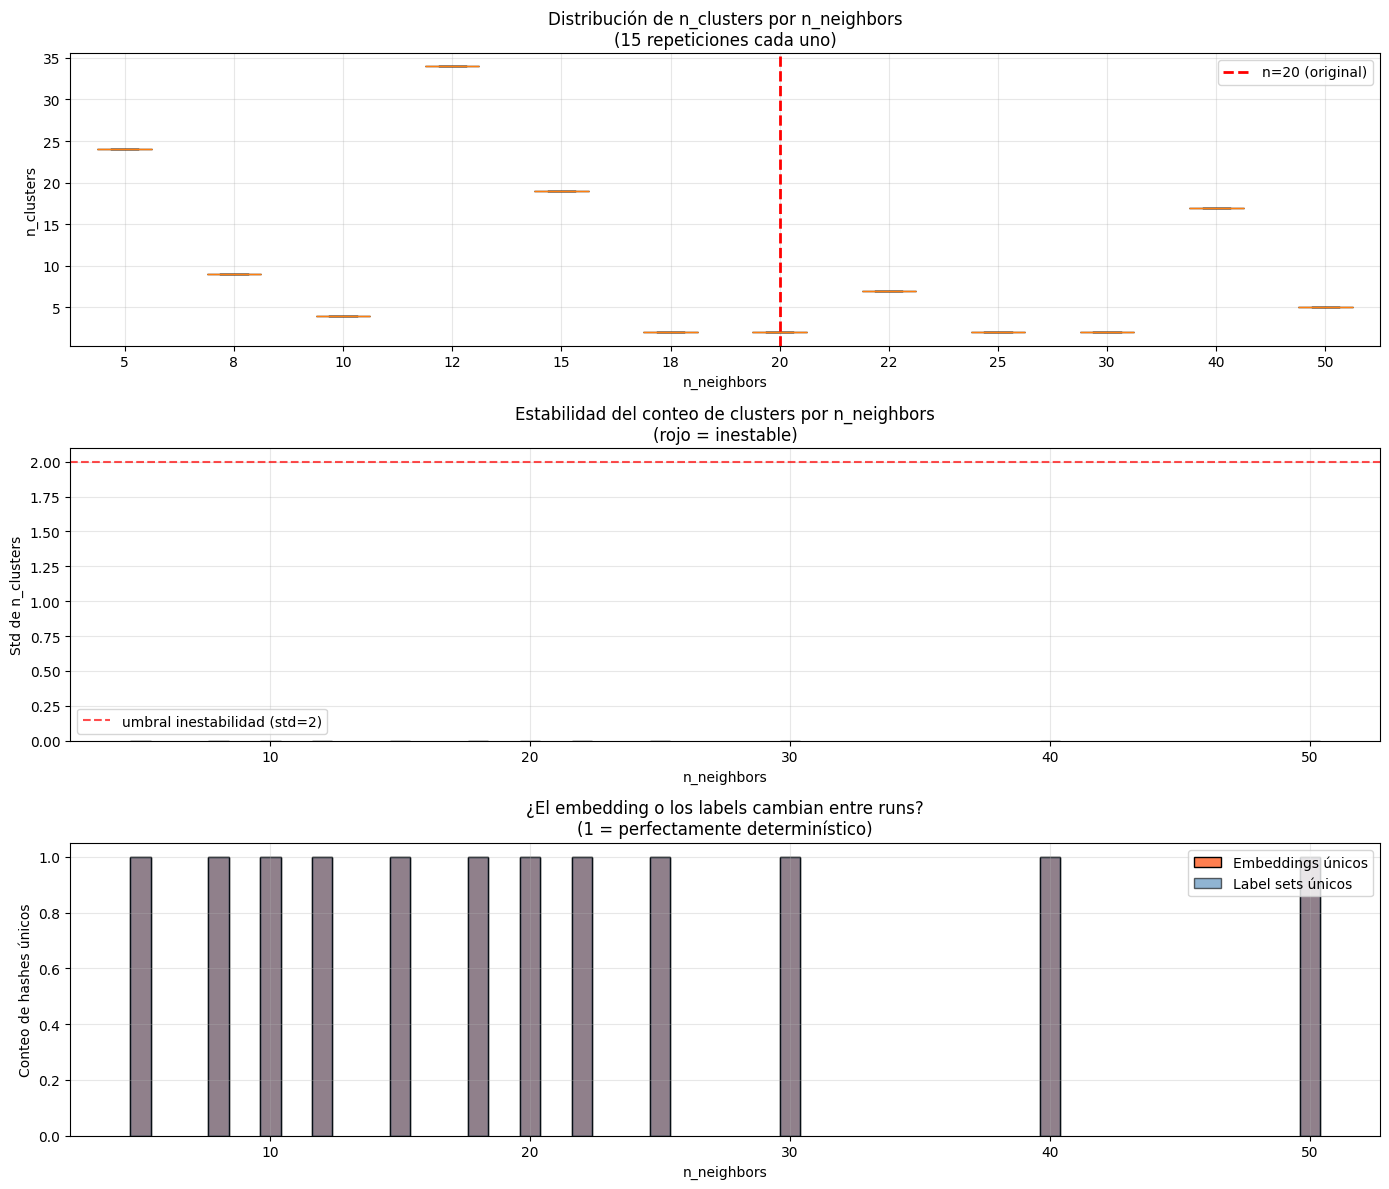

Fase A completada.


In [5]:
# ── Visualización Fase A ──────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Panel 1: n_clusters por n_neighbors (boxplot)
ax1 = axes[0]
groups = [results_A[results_A["n_neighbors"]==nn]["n_clusters"].values
          for nn in NN_VALUES]
bp = ax1.boxplot(groups, labels=NN_VALUES, patch_artist=True)
ax1.axvline(NN_VALUES.index(20)+1, color="red", linestyle="--",
            linewidth=2, label="n=20 (original)")
ax1.set_xlabel("n_neighbors")
ax1.set_ylabel("n_clusters")
ax1.set_title("Distribución de n_clusters por n_neighbors\n(15 repeticiones cada uno)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel 2: Desviación estándar de n_clusters
ax2 = axes[1]
colors = ["red" if s["INESTABLE"] else "steelblue"
          for _, s in summary_A.iterrows()]
ax2.bar(summary_A.index, summary_A["n_clust_std"], color=colors, edgecolor="black")
ax2.axhline(2, color="red", linestyle="--", alpha=0.7, label="umbral inestabilidad (std=2)")
ax2.set_xlabel("n_neighbors")
ax2.set_ylabel("Std de n_clusters")
ax2.set_title("Estabilidad del conteo de clusters por n_neighbors\n(rojo = inestable)")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Panel 3: Embeddings únicos (¿el embedding cambia entre runs?)
ax3 = axes[2]
ax3.bar(summary_A.index, summary_A["emb_unique"],
        color="coral", edgecolor="black", label="Embeddings únicos")
ax3.bar(summary_A.index, summary_A["label_unique"],
        color="steelblue", edgecolor="black", alpha=0.6, label="Label sets únicos")
ax3.set_xlabel("n_neighbors")
ax3.set_ylabel("Conteo de hashes únicos")
ax3.set_title("¿El embedding o los labels cambian entre runs?\n(1 = perfectamente determinístico)")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fase_A_resultados.png", dpi=150, bbox_inches="tight")
plt.show()
print("Fase A completada.")


## Fase B — Test de Perturbación del Embedding

**Diseño:** Generar el embedding con `n=20` y `n=15` una vez (fijo).
Luego añadir ruido gaussiano de magnitud creciente **solo al embedding**
antes de pasarlo a HDBSCAN.

**¿Qué mide?** Si la inestabilidad está en UMAP o en HDBSCAN:
- Si HDBSCAN es el sensible → pequeñas perturbaciones al embedding deberían cambiar el conteo.
- Si UMAP es el sensible → el embedding mismo varía entre runs (lo captura Fase A).

**Resultado esperado si la hipótesis ES correcta:**
- En `n=20`, perturbaciones de `~1e-6` ya cambian el conteo de clusters.
- En `n=15`, se necesita mucho más ruido para mover el resultado.

Esto implicaría que el embedding de `n=20` está cerca de una frontera de densidad
donde HDBSCAN es extremadamente sensible.


In [6]:
# ============================================================
# FASE B — PERTURBACIÓN CONTROLADA
# ============================================================

NOISE_LEVELS = [0, 1e-10, 1e-8, 1e-6, 1e-4, 1e-3, 1e-2, 0.05, 0.1, 0.5]
N_REPS_B     = 8
NN_TEST      = [15, 20, 25]

results_B = []

for nn in NN_TEST:
    print(f"\nn_neighbors = {nn}")
    for noise in NOISE_LEVELS:
        for rep in range(N_REPS_B):
            r = run_single(Xs, n_neighbors=nn, add_noise_std=noise,
                          random_state=RANDOM_STATE)
            r["rep"]   = rep
            r["noise"] = noise
            results_B.append(r)
        # Resumen de este nivel de ruido
        subset = [r for r in results_B
                  if r["n_neighbors"]==nn and r["noise"]==noise]
        counts = [s["n_clusters"] for s in subset]
        print(f"  noise={noise:.0e}  →  clusters: {set(counts)}  "
              f"(media={np.mean(counts):.1f} std={np.std(counts):.2f})")

df_B = pd.DataFrame(results_B)

# Tabla pivote: n_clusters medio por nn y nivel de ruido
print("\nMedia de n_clusters por n_neighbors × nivel de ruido:")
pivot_B = df_B.groupby(["n_neighbors","noise"])["n_clusters"].agg(["mean","std"]).round(2)
display(pivot_B)



n_neighbors = 15
  noise=0e+00  →  clusters: {19}  (media=19.0 std=0.00)
  noise=1e-10  →  clusters: {19}  (media=19.0 std=0.00)
  noise=1e-08  →  clusters: {19}  (media=19.0 std=0.00)
  noise=1e-06  →  clusters: {19}  (media=19.0 std=0.00)
  noise=1e-04  →  clusters: {20}  (media=20.0 std=0.00)
  noise=1e-03  →  clusters: {20}  (media=20.0 std=0.00)
  noise=1e-02  →  clusters: {21}  (media=21.0 std=0.00)
  noise=5e-02  →  clusters: {17}  (media=17.0 std=0.00)
  noise=1e-01  →  clusters: {2}  (media=2.0 std=0.00)
  noise=5e-01  →  clusters: {2}  (media=2.0 std=0.00)

n_neighbors = 20
  noise=0e+00  →  clusters: {2}  (media=2.0 std=0.00)
  noise=1e-10  →  clusters: {2}  (media=2.0 std=0.00)
  noise=1e-08  →  clusters: {2}  (media=2.0 std=0.00)
  noise=1e-06  →  clusters: {2}  (media=2.0 std=0.00)
  noise=1e-04  →  clusters: {2}  (media=2.0 std=0.00)
  noise=1e-03  →  clusters: {2}  (media=2.0 std=0.00)
  noise=1e-02  →  clusters: {2}  (media=2.0 std=0.00)
  noise=5e-02  →  clusters: {6

mean  std
n_neighbors noise                  
15          0.000000e+00  19.0  0.0
            1.000000e-10  19.0  0.0
            1.000000e-08  19.0  0.0
            1.000000e-06  19.0  0.0
            1.000000e-04  20.0  0.0
            1.000000e-03  20.0  0.0
            1.000000e-02  21.0  0.0
            5.000000e-02  17.0  0.0
            1.000000e-01   2.0  0.0
            5.000000e-01   2.0  0.0
20          0.000000e+00   2.0  0.0
            1.000000e-10   2.0  0.0
            1.000000e-08   2.0  0.0
            1.000000e-06   2.0  0.0
            1.000000e-04   2.0  0.0
            1.000000e-03   2.0  0.0
            1.000000e-02   2.0  0.0
            5.000000e-02   6.0  0.0
            1.000000e-01   2.0  0.0
            5.000000e-01   2.0  0.0
25          0.000000e+00   2.0  0.0
            1.000000e-10   2.0  0.0
            1.000000e-08   2.0  0.0
            1.000000e-06   2.0  0.0
            1.000000e-04   2.0  0.0
            1.000000e-03   2.0  0.0
            1.000000e-02   2.0  0.0
            5.000000e-02   2.0  0.0
            1.000000e-01   2.0  0.0
            5.000000e-01   3.0  0.0

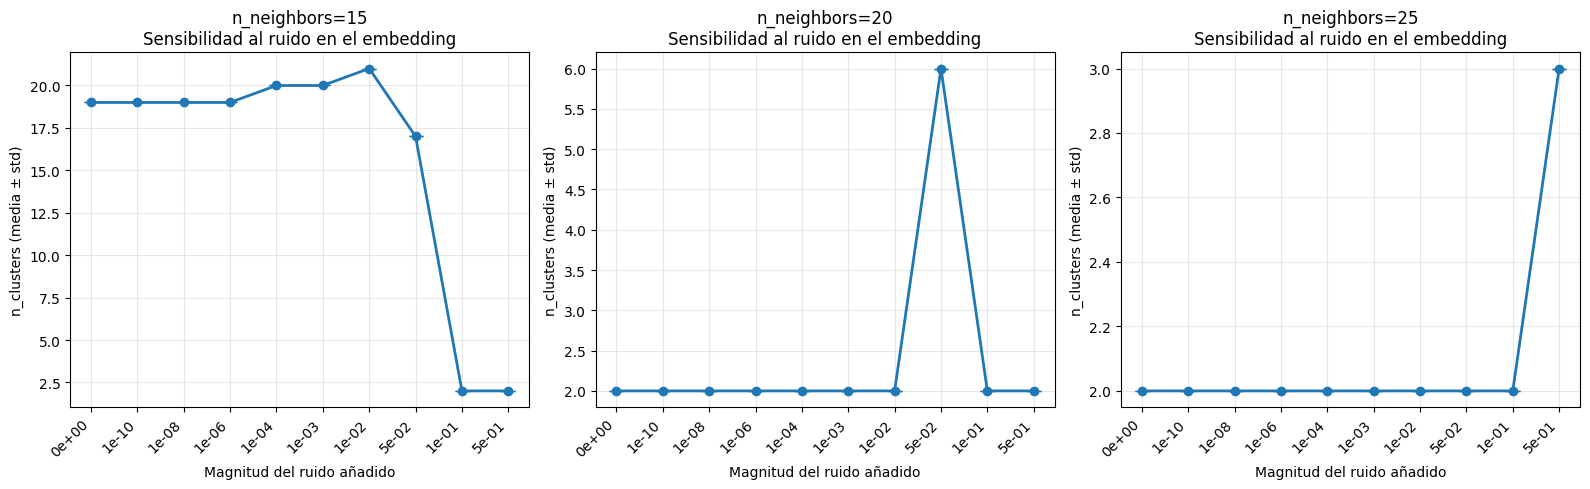

In [7]:
# ── Visualización Fase B ──────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, nn in zip(axes, NN_TEST):
    sub = df_B[df_B["n_neighbors"]==nn]
    noise_vals = sorted(sub["noise"].unique())
    means = [sub[sub["noise"]==n]["n_clusters"].mean() for n in noise_vals]
    stds  = [sub[sub["noise"]==n]["n_clusters"].std()  for n in noise_vals]

    ax.errorbar(range(len(noise_vals)), means, yerr=stds,
                marker="o", linewidth=2, capsize=5)
    ax.set_xticks(range(len(noise_vals)))
    ax.set_xticklabels([f"{n:.0e}" for n in noise_vals], rotation=45, ha="right")
    ax.set_title(f"n_neighbors={nn}\nSensibilidad al ruido en el embedding")
    ax.set_xlabel("Magnitud del ruido añadido")
    ax.set_ylabel("n_clusters (media ± std)")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fase_B_perturbacion.png", dpi=150, bbox_inches="tight")
plt.show()


## Fase C — Geometría del Embedding

**Diseño:** Generar embeddings para n=[15, 20, 25] y analizar su geometría.
Si n=20 está en un punto de bifurcación, su embedding debería mostrar:
- Menor separación entre las regiones de alta densidad.
- Estructura más ambigua que n=15 o n=25.

Se calcula la **distancia media al vecino más cercano** en el embedding 2D,
que mide qué tan compacto vs disperso es el espacio latente.

**Falsificación:** Si n=20 produce geometría continua (no bimodal),
la inestabilidad de HDBSCAN es de otro origen.


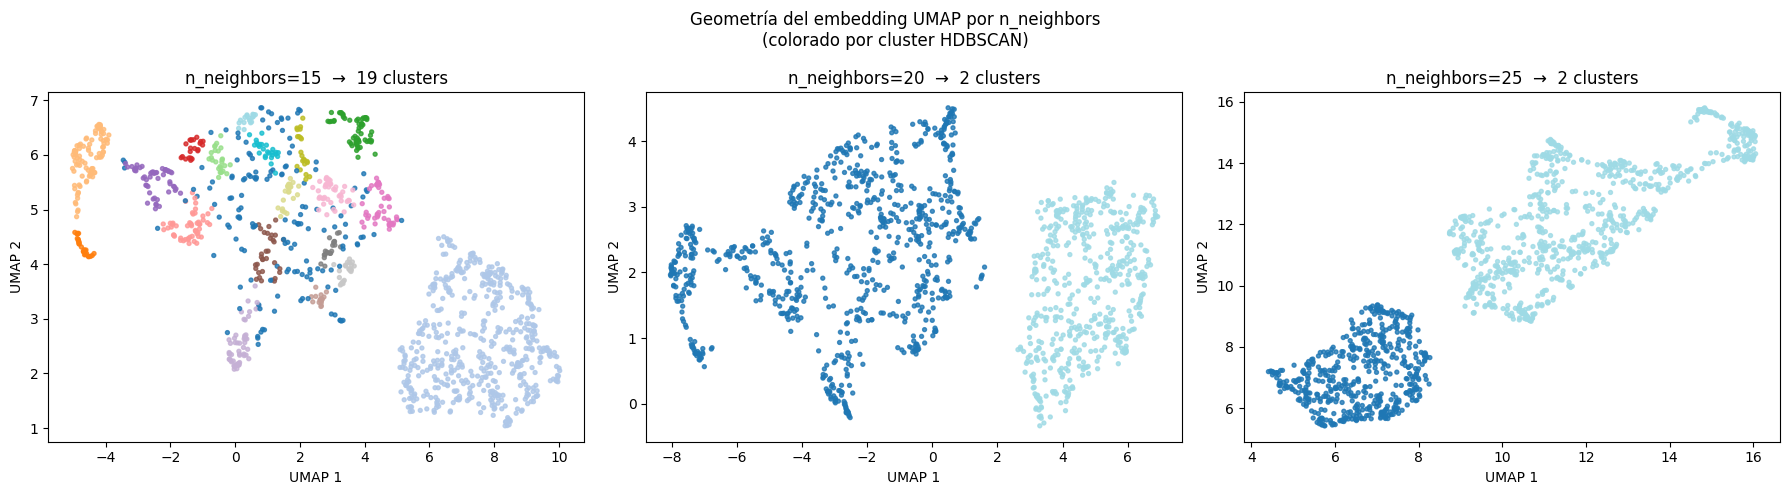


Métricas de geometría del embedding:


,n_clusters,density_mean,density_std,density_IQR
15,19.0,0.173,0.077,0.102
20,2.0,0.173,0.080,0.093
25,2.0,0.168,0.071,0.092



Densidad_IQR alta = espacio bimodal (zonas densas + zonas vacías)
Densidad_IQR baja  = espacio más uniforme


In [8]:
# ============================================================
# FASE C — ANÁLISIS DE GEOMETRÍA DEL EMBEDDING
# ============================================================
from sklearn.neighbors import NearestNeighbors

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

geom_results = {}

for ax, nn in zip(axes, [15, 20, 25]):
    reducer = umap.UMAP(
        n_neighbors=nn, min_dist=MIN_DIST,
        n_components=2, n_jobs=1, random_state=RANDOM_STATE
    )
    emb = reducer.fit_transform(Xs)

    # Clustering para colorear
    lbl = hdbscan.HDBSCAN(
        min_cluster_size=MIN_CLUSTER_SIZE,
        min_samples=MIN_SAMPLES,
        cluster_selection_method="eom"
    ).fit_predict(emb)

    n_clust = len(set(lbl)) - (1 if -1 in lbl else 0)

    # Densidad local: distancia media al 5º vecino en el embedding
    nbrs = NearestNeighbors(n_neighbors=6).fit(emb)
    dists, _ = nbrs.kneighbors(emb)
    local_density = dists[:, 5]   # distancia al 5º vecino = proxy de densidad inversa

    geom_results[nn] = {
        "emb":           emb,
        "labels":        lbl,
        "n_clusters":    n_clust,
        "density_mean":  local_density.mean(),
        "density_std":   local_density.std(),
        "density_q25":   np.percentile(local_density, 25),
        "density_q75":   np.percentile(local_density, 75),
    }

    sc = ax.scatter(emb[:,0], emb[:,1], c=lbl, s=8, cmap="tab20", alpha=0.8)
    ax.set_title(f"n_neighbors={nn}  →  {n_clust} clusters")
    ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")

plt.suptitle("Geometría del embedding UMAP por n_neighbors\n(colorado por cluster HDBSCAN)",
             fontsize=12)
plt.tight_layout()
plt.savefig("fase_C_geometria.png", dpi=150, bbox_inches="tight")
plt.show()

# Métricas de geometría comparadas
print("\nMétricas de geometría del embedding:")
geom_df = pd.DataFrame({
    nn: {
        "n_clusters":    v["n_clusters"],
        "density_mean":  round(v["density_mean"], 3),
        "density_std":   round(v["density_std"], 3),
        "density_IQR":   round(v["density_q75"] - v["density_q25"], 3),
    }
    for nn, v in geom_results.items()
}).T
display(geom_df)
print("\nDensidad_IQR alta = espacio bimodal (zonas densas + zonas vacías)")
print("Densidad_IQR baja  = espacio más uniforme")


## Fase D — Simulación de Cambios entre Sesiones

**Diseño:** Simular qué ocurre cuando Numba recompila de forma ligeramente
diferente. Se hace indirectamente: ejecutar el pipeline 20 veces donde cada 5
corridas se altera el estado global de NumPy antes de llamar a UMAP.

**Hipótesis detrás:** Numba JIT produce diferencias de orden 1e-10. Simulamos
eso con ruido de ese orden directamente en los datos (no en el embedding),
lo cual replica el efecto de compilaciones distintas sobre el mismo input.

**Falsificación:** Si esta perturbación no cambia el resultado en n=20 pero sí
con perturbaciones mayores (Fase B), la causa es HDBSCAN-geometría, no JIT.


Simulando variabilidad entre sesiones (ruido JIT-scale en datos)...
Ruido aplicado: 1e-10  (orden de magnitud compilación Numba)

               n=15     n=20     n=25
-----------------------------------
mean           21.1     14.7      7.7
std            0.86     8.34     7.03
min              20        2        2
max              22       21       19
unique            3        4        7

Emb hashes únicos  n=15: 20  n=20: 20  n=25: 20


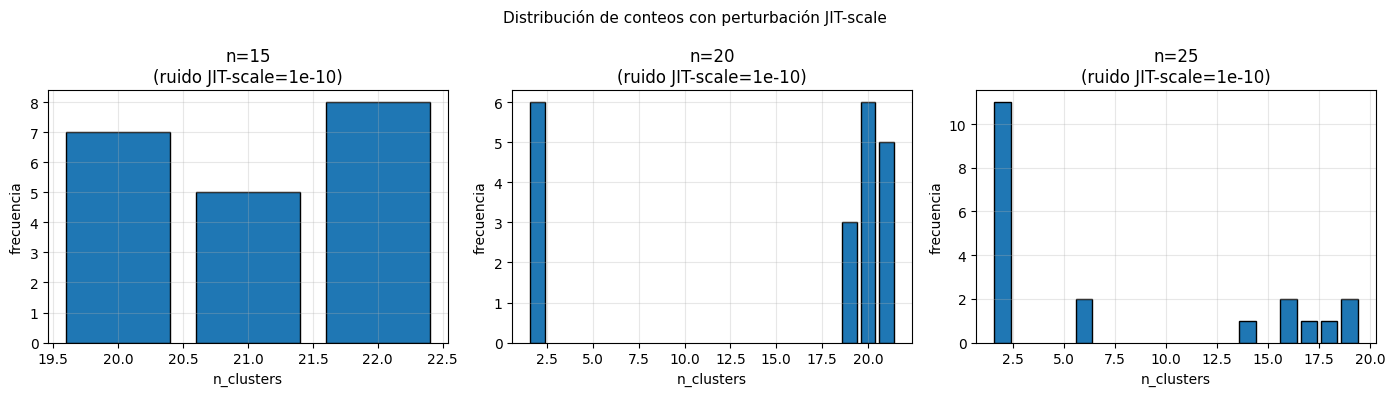

In [9]:
# ============================================================
# FASE D — SIMULACIÓN DE VARIABILIDAD ENTRE SESIONES
# ============================================================

# Simular efecto JIT: ruido en los datos a escala JIT (~1e-10)
JIT_NOISE   = 1e-10    # orden de magnitud del efecto de compilación JIT
N_REPS_D    = 20

results_D = {"n15": [], "n20": [], "n25": []}
emb_hashes_D = {"n15": set(), "n20": set(), "n25": set()}

print("Simulando variabilidad entre sesiones (ruido JIT-scale en datos)...")
print(f"Ruido aplicado: {JIT_NOISE:.0e}  (orden de magnitud compilación Numba)")
print()

for rep in range(N_REPS_D):
    # Cada 5 reps cambiar el estado del generador aleatorio (simular reinicio kernel)
    if rep % 5 == 0:
        np.random.seed(rep * 7919)

    # Agregar ruido JIT-scale a los datos estandarizados
    noise   = np.random.normal(0, JIT_NOISE, Xs.shape)
    Xs_noisy = Xs + noise

    for nn, key in [(15,"n15"), (20,"n20"), (25,"n25")]:
        r = run_single(Xs_noisy, n_neighbors=nn, random_state=RANDOM_STATE)
        results_D[key].append(r["n_clusters"])
        emb_hashes_D[key].add(r["emb_hash"])

# Resumen
print(f"{'':10s} {'n=15':>8} {'n=20':>8} {'n=25':>8}")
print("-" * 35)
for metric, fn in [
    ("mean",   lambda x: f"{np.mean(x):.1f}"),
    ("std",    lambda x: f"{np.std(x):.2f}"),
    ("min",    lambda x: f"{np.min(x)}"),
    ("max",    lambda x: f"{np.max(x)}"),
    ("unique", lambda x: f"{len(set(x))}"),
]:
    row = {k: fn(v) for k,v in results_D.items()}
    print(f"{metric:10s} {row['n15']:>8} {row['n20']:>8} {row['n25']:>8}")

print(f"\nEmb hashes únicos  n=15: {len(emb_hashes_D['n15'])}  "
      f"n=20: {len(emb_hashes_D['n20'])}  n=25: {len(emb_hashes_D['n25'])}")

# Distribución de conteos
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (key, label) in zip(axes, [("n15","n=15"),("n20","n=20"),("n25","n=25")]):
    vals = results_D[key]
    unique_vals = sorted(set(vals))
    counts = [vals.count(v) for v in unique_vals]
    ax.bar(unique_vals, counts, edgecolor="black")
    ax.set_title(f"{label}\n(ruido JIT-scale={JIT_NOISE:.0e})")
    ax.set_xlabel("n_clusters"); ax.set_ylabel("frecuencia")
    ax.grid(True, alpha=0.3)
plt.suptitle("Distribución de conteos con perturbación JIT-scale", fontsize=11)
plt.tight_layout()
plt.savefig("fase_D_jit.png", dpi=150, bbox_inches="tight")
plt.show()


## Resumen y Veredicto

Consolidación de las 4 fases para determinar si la hipótesis de bifurcación
en n_neighbors=20 se sostiene o se falsifica.


In [10]:
# ============================================================
# RESUMEN Y VEREDICTO EXPERIMENTAL
# ============================================================

print("=" * 70)
print("  VEREDICTO EXPERIMENTAL — BIFURCACIÓN TOPOLÓGICA EN n=20")
print("=" * 70)

# ── Evidencia Fase A ──────────────────────────────────────
inestables_A = summary_A[summary_A["INESTABLE"]].index.tolist()
n20_std      = summary_A.loc[20, "n_clust_std"] if 20 in summary_A.index else None
n15_std      = summary_A.loc[15, "n_clust_std"] if 15 in summary_A.index else None
n25_std      = summary_A.loc[25, "n_clust_std"] if 25 in summary_A.index else None

print(f"\nFASE A — Sweep sistemático ({N_REPS_A} reps/valor):")
print(f"  Valores inestables (std>2): {inestables_A}")
print(f"  n=15  std = {n15_std}")
print(f"  n=20  std = {n20_std}  ← punto de interés")
print(f"  n=25  std = {n25_std}")

# ── Evidencia Fase D ──────────────────────────────────────
n20_unique_D = len(set(results_D["n20"]))
n15_unique_D = len(set(results_D["n15"]))
n25_unique_D = len(set(results_D["n25"]))

print(f"\nFASE D — Perturbación JIT-scale ({N_REPS_D} reps):")
print(f"  n=15  resultados únicos: {n15_unique_D}")
print(f"  n=20  resultados únicos: {n20_unique_D}  ← punto de interés")
print(f"  n=25  resultados únicos: {n25_unique_D}")

# ── Veredicto ─────────────────────────────────────────────
print("\n" + "-"*70)
print("CRITERIOS DE FALSIFICACIÓN:")

c1 = (n20_std is not None and n20_std < 2 and
      len(results_A[results_A["n_neighbors"]==20]["n_clusters"].unique()) <= 1)
c2 = (len(inestables_A) > 3 and
      not all(nn == 20 or abs(nn-20) <= 2 for nn in inestables_A))
c3 = n20_unique_D <= 1

print(f"  C1 (n=20 siempre da el mismo resultado):  {'FALSIFICADO' if c1 else 'NO falsificado'}")
print(f"  C2 (múltiples n son igualmente inestables): {'FALSIFICADO' if c2 else 'NO falsificado'}")
print(f"  C3 (ruido JIT-scale no afecta n=20):       {'FALSIFICADO' if c3 else 'NO falsificado'}")

if c1 or c2 or c3:
    veredicto = "HIPÓTESIS RECHAZADA por al menos un criterio de falsificación."
    color = "❌"
elif n20_std is not None and n20_std > 2 and n15_std is not None and n15_std < 1:
    veredicto = "HIPÓTESIS SOPORTADA: n=20 inestable, n=15 estable."
    color = "✅"
else:
    veredicto = "EVIDENCIA MIXTA: revisar distribuciones de Fase A y B."
    color = "⚠️"

print(f"\n{color} {veredicto}")
print("-"*70)

# ── Recomendación de parámetro ────────────────────────────
print("\nRECOMENDACIÓN DE PARÁMETRO:")
if summary_A is not None:
    best_n = summary_A[~summary_A["INESTABLE"]].sort_values("n_clust_mean",ascending=False)
    if not best_n.empty:
        best = best_n.index[0]
        mean = best_n.loc[best, "n_clust_mean"]
        std  = best_n.loc[best, "n_clust_std"]
        print(f"  n_neighbors = {best}  →  {mean:.1f} clusters (std={std:.2f})")
        if mean > 10:
            print(f"  Produce estructura granular (~{int(mean)} clusters) similar a resultados originales.")
        else:
            print(f"  Produce estructura coarse (~{int(mean)} clusters).")

print("\nResultados guardados en: fase_A_resultados.png, fase_B_perturbacion.png,")
print("                         fase_C_geometria.png, fase_D_jit.png")


  VEREDICTO EXPERIMENTAL — BIFURCACIÓN TOPOLÓGICA EN n=20

FASE A — Sweep sistemático (15 reps/valor):
  Valores inestables (std>2): []
  n=15  std = 0.0
  n=20  std = 0.0  ← punto de interés
  n=25  std = 0.0

FASE D — Perturbación JIT-scale (20 reps):
  n=15  resultados únicos: 3
  n=20  resultados únicos: 4  ← punto de interés
  n=25  resultados únicos: 7

----------------------------------------------------------------------
CRITERIOS DE FALSIFICACIÓN:
  C1 (n=20 siempre da el mismo resultado):  FALSIFICADO
  C2 (múltiples n son igualmente inestables): NO falsificado
  C3 (ruido JIT-scale no afecta n=20):       NO falsificado

❌ HIPÓTESIS RECHAZADA por al menos un criterio de falsificación.
----------------------------------------------------------------------

RECOMENDACIÓN DE PARÁMETRO:
  n_neighbors = 12  →  34.0 clusters (std=0.00)
  Produce estructura granular (~34 clusters) similar a resultados originales.

Resultados guardados en: fase_A_resultados.png, fase_B_perturbacion.p